In [1]:
 import sys, subprocess

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, '-m', 'pip', 'install', '-q',
         'qiskit', 'qiskit-machine-learning', 'torch', 'torchvision',
         'numpy', 'pandas', 'matplotlib', 'scipy', 'pylatexenc'],
        check=True,
    )
    print('Dependencias instaladas (Colab).')
else:
    print('Entorno local: se usa el kernel actual, no se instala nada.')

Entorno local: se usa el kernel actual, no se instala nada.


# E6 · Correlación métrica ↔ precisión de clasificación

**Notebook 03 — ¿predicen la expresibilidad y el entrelazamiento el rendimiento real?**

Para varias familias de circuito (todas a **4 qubits**, para no cambiar la CNN ni los 3 observables del pipeline de producción `Hybrid CNN-QNN.ipynb`) se:

1. entrena la HQNN (CNN + `EstimatorQNN` + `TorchConnector`) en la tarea de ruido mixto,
2. mide su accuracy de test,
3. calcula la expresibilidad ($D_{KL}$) y el entrelazamiento ($Q$) del circuito con `qexpr.py`,
4. se correlacionan ambas magnitudes.

> **Antes de lanzarlo.** El coste es `len(CONFIGS) × len(SEEDS)` entrenamientos completos.
> En CPU cada uno ronda los **10 minutos**, así que la configuración por defecto
> (6 circuitos × 1 semilla) tarda alrededor de **una hora**. Con `SEEDS = [42, 43, 44]`
> son unas **tres horas**. Ajusta `SEEDS` y `EPOCHS` según el tiempo del que dispongas.

### Qué se ha corregido respecto a la versión anterior

| # | Problema | Corrección |
|---|---|---|
| 1 | La celda del barrido tenía un paréntesis sin cerrar y no respetaba la firma de `train_eval` (`SyntaxError`). | Llamada corregida a `train_eval(fm, an, ent, reps, seed)`. |
| 2 | La primera celda sobrescribía el `requirements.txt` del repositorio. | Instalación sin escribir en el repositorio, y solo en Colab. |
| 3 | `DATA_ROOT` apuntaba fuera del repositorio y volvía a descargar MNIST. | Apunta a `data/` del propio repositorio. |
| 4 | Las salidas (`E6_*.csv/png`) se escribían fuera del árbol del repositorio y no quedaban versionadas. | Van a `outputs/` dentro del repositorio; `TFM_OUTPUT_DIR` lo redirige. |
| 5 | El dataset dependía del estado global de los RNG: re-ejecutar la celda daba otros datos. | Se fijan los RNG justo antes de construirlo, con `DATA_SEED` independiente. |
| 6 | Una sola semilla por configuración, sin medida de dispersión. | Eje `SEEDS`; la tabla agrega media, desviación, mínimo y máximo. |
| 7 | Solo se reportaba el coeficiente $r$, sin significación. | Se añaden los $p$-valores (requiere `scipy`). |
| 8 | Los descriptores se recalculaban en cada entrenamiento. | Se calculan una vez por configuración, con semilla propia `DESC_SEED`. |

In [2]:
import os, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader, random_split

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorEstimator
from qiskit.circuit.library import real_amplitudes, efficient_su2, zz_feature_map, pauli_feature_map
from qiskit.quantum_info import SparsePauliOp
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

REPO_ROOT = os.getcwd()
sys.path.insert(0, REPO_ROOT)
import qexpr as qx

# --- Parametros del estudio ---------------------------------------------
SEEDS     = [42]      # semillas de ENTRENAMIENTO. Usa [42, 43, 44] para el estudio multi-semilla
DATA_SEED = 42        # semilla del dataset: FIJA, para que entre semillas solo cambie la inicializacion
DESC_SEED = 42        # semilla del muestreo de fidelidades (descriptores del circuito)

EPOCHS    = 8         # subelo para las cifras finales
LR        = 1e-3
N_SAMPLES = 2000      # muestras para las metricas de circuito (el paper usa ~5000)
N_BINS    = 75
N_QUBITS  = 4

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

# --- Salidas -------------------------------------------------------------
# Por defecto DENTRO del repositorio, para que los artefactos que cita la memoria
# sean trazables. Define TFM_OUTPUT_DIR si prefieres mandarlos a otro sitio.
OUTPUT_DIR  = os.environ.get('TFM_OUTPUT_DIR', os.path.join(REPO_ROOT, 'outputs'))
TABLES_DIR  = os.path.join(OUTPUT_DIR, 'tables')
FIGURES_DIR = os.path.join(OUTPUT_DIR, 'figures')
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)
print('tablas  ->', TABLES_DIR)
print('figuras ->', FIGURES_DIR)

try:
    from scipy import stats as _stats
except ImportError:
    _stats = None
    print('AVISO: scipy no disponible, no se calcularan p-valores.')

device: cuda
tablas  -> c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\outputs\tables
figuras -> c:\Users\SergioHF\Desktop\Mi interés\Computación Quántica\Quanvolutional_NN_classify_reconstruct\outputs\figures


## Dataset de ruido mixto (idéntico al pipeline del TFM)

El dataset se construye **una sola vez** con `DATA_SEED` y se reutiliza para todas
las configuraciones y todas las semillas de entrenamiento. Así, lo único que
cambia al variar `SEEDS` es la inicialización de la red y el orden de los lotes,
que es justamente el efecto que se quiere aislar.

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

# data/ del propio repositorio (esta en .gitignore, y ya contiene MNIST descargado)
DATA_ROOT = os.path.join(REPO_ROOT, 'data')

X_train = datasets.MNIST(root=DATA_ROOT, train=True, download=True, transform=transform)
X_test = datasets.MNIST(root=DATA_ROOT, train=False, download=True, transform=transform)

n_samples_train, n_samples_test = 400, 100
X_train.data = X_train.data[:n_samples_train]
X_train.targets = X_train.targets[:n_samples_train]
X_test.data = X_test.data[:n_samples_test]
X_test.targets = X_test.targets[:n_samples_test]

g = torch.Generator().manual_seed(DATA_SEED)
train_subset, val_subset = random_split(X_train, [300, 100], generator=g)

# Parametros de ruido de config/common.yaml
def gaussian_noise(img, sigma=0.25):
    return torch.clamp(img + torch.randn_like(img) * sigma, 0, 1)

def salt_pepper(img, prob=0.15):
    noisy = img.clone(); mask = torch.rand_like(img)
    noisy[mask < prob / 2] = 0; noisy[mask > 1 - prob / 2] = 1
    return noisy

def speckle(img, sigma=0.35):
    return torch.clamp(img + img * torch.randn_like(img) * sigma, 0, 1)

def apply_mixed_noise(img):
    r = np.random.randint(3)
    if r == 0:
        img = speckle(gaussian_noise(img)); label = 0
    elif r == 1:
        img = salt_pepper(gaussian_noise(img)); label = 1
    else:
        img = speckle(salt_pepper(img)); label = 2
    return img, label

class NoisyMNISTDataset(Dataset):
    def __init__(self, mnist_dataset):
        self.noisy_images, self.labels = [], []
        for img, _ in mnist_dataset:
            noisy_img, label = apply_mixed_noise(img)
            self.noisy_images.append(noisy_img); self.labels.append(label)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.noisy_images[idx], self.labels[idx]

# El ruido y la eleccion de clase consumen los RNG globales de torch y numpy.
# Se fijan AQUI para que la celda sea idempotente: re-ejecutarla reconstruye
# exactamente el mismo dataset, independientemente de lo que se haya corrido antes.
torch.manual_seed(DATA_SEED)
np.random.seed(DATA_SEED)

train_loader = DataLoader(NoisyMNISTDataset(train_subset), batch_size=32, shuffle=True)
val_loader = DataLoader(NoisyMNISTDataset(val_subset), batch_size=32, shuffle=False)
test_loader = DataLoader(NoisyMNISTDataset(X_test), batch_size=32, shuffle=False)

print('batches train/val/test:', len(train_loader), len(val_loader), len(test_loader))
print('soporte por clase (test):',
      np.bincount(np.asarray(test_loader.dataset.labels, dtype=int), minlength=3))

batches train/val/test: 10 4 4
soporte por clase (test): [33 41 26]


## QNN + red híbrida (parametrizadas por la familia de circuito)

In [4]:
estimator = StatevectorEstimator()
observables = [
    SparsePauliOp.from_list([('ZIII', 1.0), ('IZII', 1.0)]),
    SparsePauliOp.from_list([('ZZII', 1.0)]),
    SparsePauliOp.from_list([('IIZZ', 1.0)]),
]

def build_fm_ansatz(fm_name, an_name, an_entanglement, reps, n_qubits=N_QUBITS):
    if fm_name == 'zz':
        fm = zz_feature_map(n_qubits, entanglement='full', reps=1)
    else:
        fm = pauli_feature_map(n_qubits, paulis=['X', 'Y', 'ZZ'], entanglement='full', reps=1)
    if an_name == 'real_amplitudes':
        an = real_amplitudes(n_qubits, entanglement=an_entanglement, reps=reps)
    else:
        an = efficient_su2(n_qubits, entanglement=an_entanglement, reps=reps)
    qc = QuantumCircuit(n_qubits)
    qc.compose(fm, inplace=True)
    qc.compose(an, inplace=True)
    return fm, an, qc

def create_qnn(fm, an, qc):
    return EstimatorQNN(circuit=qc, input_params=fm.parameters, weight_params=an.parameters,
                        input_gradients=True, estimator=estimator, observables=observables)

class Net(nn.Module):
    def __init__(self, qnn):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, N_QUBITS)
        self.qnn = TorchConnector(qnn)
        self.fc_final = nn.Identity()
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = torch.tanh(self.fc2(x)) * np.pi
        return self.fc_final(self.qnn(x))

In [5]:
# Entrena la HQNN para una familia de circuito y una semilla concreta.
# Devuelve (accuracy de test, segundos de entrenamiento).
def train_eval(fm_name, an_name, an_entanglement, reps, seed):
    torch.manual_seed(seed)
    np.random.seed(seed)

    fm, an, qc = build_fm_ansatz(fm_name, an_name, an_entanglement, reps)
    model = Net(create_qnn(fm, an, qc)).to(device)
    opt = optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss()

    t0 = time.time()
    for _ in range(EPOCHS):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            opt.zero_grad(); loss = crit(model(data), target); loss.backward(); opt.step()
    secs = time.time() - t0

    model.eval(); correct = total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            _, pred = torch.max(model(data), 1)
            correct += (pred == target).sum().item(); total += target.size(0)

    return correct / total, secs


# Descriptores del circuito. No dependen de la semilla de entrenamiento, asi que
# se calculan una sola vez por configuracion y con su propia semilla (DESC_SEED).
def circuit_descriptors(fm_name, an_name, an_entanglement, reps):
    _, _, qc = build_fm_ansatz(fm_name, an_name, an_entanglement, reps)
    return qx.descriptors(qc, N_QUBITS, n_samples=N_SAMPLES, n_bins=N_BINS, seed=DESC_SEED)

## Configuraciones candidatas (todas a 4 qubits)

Las dos primeras filas son un **control interno**: para `RealAmplitudes` con
`reps=1`, los entrelazamientos `full` y `reverse_linear` generan el mismo unitario
con el mismo orden de parámetros, de modo que sus descriptores han de coincidir.
Cualquier diferencia de accuracy entre ellas no puede atribuirse al circuito y mide
directamente el ruido del procedimiento de entrenamiento. La última celda del
notebook lo comprueba explícitamente.

In [6]:
# (etiqueta, feature_map, ansatz, entanglement_ansatz, reps)
CONFIGS = [
    ('zz+RA (rev_lin, r1) [prod]', 'zz',    'real_amplitudes', 'reverse_linear', 1),
    ('zz+RA (full, r1)',           'zz',    'real_amplitudes', 'full',           1),
    ('zz+RA (rev_lin, r2)',        'zz',    'real_amplitudes', 'reverse_linear', 2),
    ('zz+ESU2 (rev_lin, r1)',      'zz',    'efficient_su2',   'reverse_linear', 1),
    ('pauli+RA (rev_lin, r1)',     'pauli', 'real_amplitudes', 'reverse_linear', 1),
    ('pauli+ESU2 (rev_lin, r1)',   'pauli', 'efficient_su2',   'reverse_linear', 1),
]

n_runs = len(CONFIGS) * len(SEEDS)
print(f'{len(CONFIGS)} configuraciones x {len(SEEDS)} semilla(s) = {n_runs} entrenamientos '
      f'de {EPOCHS} epocas.')
print(f'En CPU cada entrenamiento ronda los 10 min: estimacion total ~{n_runs * 10} min.')
print()

runs = []
for label, fm, an, ent, reps in CONFIGS:
    m = circuit_descriptors(fm, an, ent, reps)
    for seed in SEEDS:
        acc, secs = train_eval(fm, an, ent, reps, seed)
        runs.append({
            'circuit': label, 'seed': seed, 'test_acc': acc, 'seconds': secs,
            'expressibility_kl': m['expressibility_kl'],
            'entangling_Q': m['entangling_Q'],
            'entangling_Q_std': m['entangling_Q_std'],
            'n_params': m['n_params'], 'depth': m['depth'],
        })
        print(f"{label:30s} seed={seed}  acc={acc:.3f}  "
              f"KL={m['expressibility_kl']:.6f}  Q={m['entangling_Q']:.6f}  ({secs:.0f}s)")

df_runs = pd.DataFrame(runs)
df_runs.to_csv(os.path.join(TABLES_DIR, 'E6_metric_vs_accuracy_runs.csv'), index=False)
df_runs

6 configuraciones x 1 semilla(s) = 6 entrenamientos de 8 epocas.
En CPU cada entrenamiento ronda los 10 min: estimacion total ~60 min.



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


zz+RA (rev_lin, r1) [prod]     seed=42  acc=0.920  KL=0.008928  Q=0.834993  (405s)


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


zz+RA (full, r1)               seed=42  acc=0.880  KL=0.008928  Q=0.834993  (430s)


...

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


pauli+RA (rev_lin, r1)         seed=42  acc=0.910  KL=0.020220  Q=0.630375  (670s)


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


pauli+ESU2 (rev_lin, r1)       seed=42  acc=0.980  KL=0.007032  Q=0.698853  (1037s)


,circuit,seed,test_acc,seconds,expressibility_kl,entangling_Q,entangling_Q_std,n_params,depth
0,"zz+RA (rev_lin, r1) [prod]",42,0.92,405.445716,0.008928,0.834993,0.101534,12,22
1,"zz+RA (full, r1)",42,0.88,429.861463,0.008928,0.834993,0.101534,12,23
2,"zz+RA (rev_lin, r2)",42,0.91,563.332685,0.006976,0.832146,0.090010,16,25
3,"zz+ESU2 (rev_lin, r1)",42,0.26,695.482803,0.007948,0.830142,0.104298,20,24
4,"pauli+RA (rev_lin, r1)",42,0.91,669.837372,0.020220,0.630375,0.177257,12,31
5,"pauli+ESU2 (rev_lin, r1)",42,0.98,1036.882140,0.007032,0.698853,0.163617,20,33


In [7]:
# Agregado por configuracion. Con una sola semilla, acc_std vale 0 y la tabla
# equivale a la del estudio original.
dfc = (df_runs
       .groupby('circuit', sort=False)
       .agg(acc_mean=('test_acc', 'mean'),
            acc_std=('test_acc', 'std'),
            acc_min=('test_acc', 'min'),
            acc_max=('test_acc', 'max'),
            n_seeds=('test_acc', 'size'),
            expressibility_kl=('expressibility_kl', 'first'),
            entangling_Q=('entangling_Q', 'first'),
            n_params=('n_params', 'first'),
            depth=('depth', 'first'))
       .reset_index())
dfc['acc_std'] = dfc['acc_std'].fillna(0.0)

dfc.to_csv(os.path.join(TABLES_DIR, 'E6_metric_vs_accuracy.csv'), index=False)
dfc

,circuit,acc_mean,acc_std,acc_min,acc_max,n_seeds,expressibility_kl,entangling_Q,n_params,depth
0,"zz+RA (rev_lin, r1) [prod]",0.92,0.0,0.92,0.92,1,0.008928,0.834993,12,22
1,"zz+RA (full, r1)",0.88,0.0,0.88,0.88,1,0.008928,0.834993,12,23
2,"zz+RA (rev_lin, r2)",0.91,0.0,0.91,0.91,1,0.006976,0.832146,16,25
3,"zz+ESU2 (rev_lin, r1)",0.26,0.0,0.26,0.26,1,0.007948,0.830142,20,24
4,"pauli+RA (rev_lin, r1)",0.91,0.0,0.91,0.91,1,0.020220,0.630375,12,31
5,"pauli+ESU2 (rev_lin, r1)",0.98,0.0,0.98,0.98,1,0.007032,0.698853,20,33


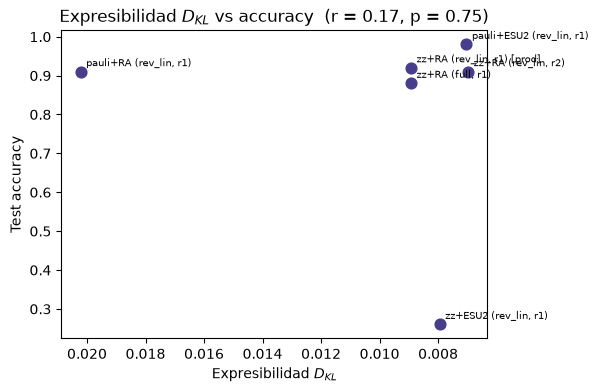

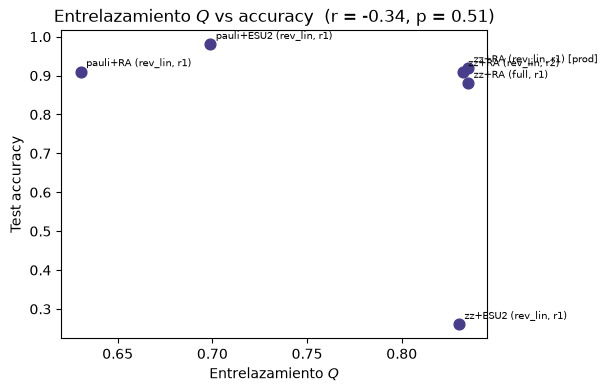

accuracy ~ KL : r = 0.167   p = 0.752
accuracy ~ Q  : r = -0.339   p = 0.511
n = 6 configuraciones, 1 semilla(s) por configuracion

Recuerda que con n = 6 configuraciones hace falta |r| > 0.81 para que p < 0.05.


In [8]:
def scatter(xcol, xlabel, fname, invert=False):
    x = dfc[xcol].values
    y = dfc['acc_mean'].values
    yerr = dfc['acc_std'].values

    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else float('nan')
    if _stats is not None and len(x) > 2:
        p = float(_stats.pearsonr(x, y)[1])
    else:
        p = float('nan')

    fig, ax = plt.subplots(figsize=(5.5, 4))
    if np.any(yerr > 0):
        ax.errorbar(x, y, yerr=yerr, fmt='o', color='darkslateblue',
                    ecolor='gray', capsize=3, markersize=7)
    else:
        ax.scatter(x, y, s=60, color='darkslateblue')
    for _, row in dfc.iterrows():
        ax.annotate(row['circuit'], (row[xcol], row['acc_mean']), fontsize=7,
                    xytext=(4, 4), textcoords='offset points')
    ax.set_xlabel(xlabel); ax.set_ylabel('Test accuracy')
    title = f'{xlabel} vs accuracy  (r = {r:.2f}'
    title = title + ')' if np.isnan(p) else title + f', p = {p:.2f})'
    ax.set_title(title)
    if invert:
        ax.invert_xaxis()
    qx.savefig(fig, os.path.join(FIGURES_DIR, fname))
    plt.show()
    return r, p

# Expresibilidad: KL menor = mas expresivo -> eje invertido para leer 'mas expresivo' a la derecha
r_expr, p_expr = scatter('expressibility_kl', 'Expresibilidad $D_{KL}$',
                         'E6_expr_vs_accuracy.png', invert=True)
r_ent, p_ent = scatter('entangling_Q', 'Entrelazamiento $Q$',
                       'E6_ent_vs_accuracy.png')

print(f'accuracy ~ KL : r = {r_expr:.3f}   p = {p_expr:.3f}')
print(f'accuracy ~ Q  : r = {r_ent:.3f}   p = {p_ent:.3f}')
print(f'n = {len(dfc)} configuraciones, {len(SEEDS)} semilla(s) por configuracion')
print()
print('Recuerda que con n = 6 configuraciones hace falta |r| > 0.81 para que p < 0.05.')

## Control: `full` y `reverse_linear` son el mismo unitario

In [9]:
# Para RealAmplitudes con reps=1, los entrelazamientos 'full' y 'reverse_linear'
# implementan EL MISMO unitario bajo el mismo orden de parametros; solo cambia el
# numero de CNOT con que se realiza. Por eso sus descriptores coinciden y
# cualquier diferencia de accuracy entre esas dos filas es ruido de entrenamiento.
from qiskit.quantum_info import Operator

a = real_amplitudes(N_QUBITS, entanglement='reverse_linear', reps=1)
b = real_amplitudes(N_QUBITS, entanglement='full', reps=1)
theta = np.random.default_rng(0).uniform(0, 2 * np.pi, a.num_parameters)

Ua = Operator(a.assign_parameters(theta))
Ub = Operator(b.assign_parameters(theta))

print('CNOT  reverse_linear / full :', a.count_ops().get('cx'), '/', b.count_ops().get('cx'))
print('max |Ua - Ub|               :', float(np.abs(Ua.data - Ub.data).max()))
print('unitarios equivalentes      :', bool(Ua.equiv(Ub)))

sub = dfc[dfc['circuit'].isin(['zz+RA (rev_lin, r1) [prod]', 'zz+RA (full, r1)'])]
if len(sub) == 2:
    gap = abs(sub['acc_mean'].iloc[0] - sub['acc_mean'].iloc[1])
    print()
    print(f'Accuracy de las dos filas: {sub["acc_mean"].iloc[0]:.3f} vs '
          f'{sub["acc_mean"].iloc[1]:.3f}  ->  brecha de {gap:.3f}')
    print('Esa brecha acota el ruido del entrenamiento: no la puede explicar el circuito.')

CNOT  reverse_linear / full : 3 / 6
max |Ua - Ub|               : 0.0
unitarios equivalentes      : True

Accuracy de las dos filas: 0.920 vs 0.880  ->  brecha de 0.040
Esa brecha acota el ruido del entrenamiento: no la puede explicar el circuito.


## Tabla lista para la memoria

In [10]:
# Tabla en formato booktabs, para pegar directamente en el capitulo 5.
lines = []
lines.append(r'\begin{tabular}{lccccc}')
lines.append(r'\toprule')
lines.append(r'Circuit & Accuracy & s.d. & $D_{KL}$ & $Q$ & Depth \\')
lines.append(r'\midrule')
for _, row in dfc.iterrows():
    label = row['circuit'].replace('_', r'\_')
    lines.append(
        f"{label} & {row['acc_mean']:.2f} & {row['acc_std']:.2f} & "
        f"{row['expressibility_kl']:.6f} & {row['entangling_Q']:.6f} & "
        f"{int(row['depth'])} " + r'\\'
    )
lines.append(r'\bottomrule')
lines.append(r'\end{tabular}')

print('\n'.join(lines))
print()
print(f'% correlaciones: accuracy~KL r={r_expr:.3f} p={p_expr:.3f} | '
      f'accuracy~Q r={r_ent:.3f} p={p_ent:.3f}')
print(f'% protocolo: {EPOCHS} epocas, Adam lr={LR}, semillas {SEEDS}, '
      f'{N_QUBITS} qubits, N_SAMPLES={N_SAMPLES}')

\begin{tabular}{lccccc}
\toprule
Circuit & Accuracy & s.d. & $D_{KL}$ & $Q$ & Depth \\
\midrule
zz+RA (rev\_lin, r1) [prod] & 0.92 & 0.00 & 0.008928 & 0.834993 & 22 \\
zz+RA (full, r1) & 0.88 & 0.00 & 0.008928 & 0.834993 & 23 \\
zz+RA (rev\_lin, r2) & 0.91 & 0.00 & 0.006976 & 0.832146 & 25 \\
zz+ESU2 (rev\_lin, r1) & 0.26 & 0.00 & 0.007948 & 0.830142 & 24 \\
pauli+RA (rev\_lin, r1) & 0.91 & 0.00 & 0.020220 & 0.630375 & 31 \\
pauli+ESU2 (rev\_lin, r1) & 0.98 & 0.00 & 0.007032 & 0.698853 & 33 \\
\bottomrule
\end{tabular}

% correlaciones: accuracy~KL r=0.167 p=0.752 | accuracy~Q r=-0.339 p=0.511
% protocolo: 8 epocas, Adam lr=0.001, semillas [42], 4 qubits, N_SAMPLES=2000


## Interpretación (para la memoria)

- Un **KL bajo** (más expresivo) y/o **Q alto** (más entrelazamiento) que se asocien a mayor accuracy respaldarían la elección del circuito; una correlación débil sugeriría que en esta tarea (dataset pequeño, features ya separables por la CNN) el circuito no es el cuello de botella.
- Con `n = 6` configuraciones, un coeficiente necesita $|r| > 0.81$ para alcanzar $p < 0.05$. Conviene por tanto reportar el $p$-valor junto al $r$ y no interpretar un $r$ moderado como evidencia.
- El control de la última celda es el argumento más fuerte disponible: si dos filas que implementan el mismo unitario difieren en accuracy, esa brecha es el suelo de ruido frente al que hay que leer cualquier diferencia entre circuitos.
- La tarea de ruido mixto es fácilmente separable (la CNN de producción llega a ~100%), por lo que el techo de accuracy puede enmascarar diferencias: conviene reportar también con la CNN congelada o menos épocas si se busca discriminar circuitos.

Artefactos generados en `outputs/`: `E6_metric_vs_accuracy.csv` (agregado),
`E6_metric_vs_accuracy_runs.csv` (una fila por ejecución),
`E6_expr_vs_accuracy.png` y `E6_ent_vs_accuracy.png`.